# Huấn luyện, Tinh chỉnh và Đánh giá Mô hình LightGBM Regressor
**Thực hiện:** Nhóm nghiên cứu & mô hình hóa dữ liệu (Lớp Học máy - UTH)

## Giới thiệu
Trong file này, chúng ta sẽ thực hiện quy trình huấn luyện mô hình học máy chuyên nghiệp bằng thuật toán **LightGBM Regressor** từ đầu (scratch) sử dụng tập dữ liệu đặc trưng đã được tối ưu hóa ở bước 2:

### Quy trình triển khai:
1. **Nạp dữ liệu:** Đọc các tập dữ liệu `X_train`, `X_test`, `y_train` (đã log), `y_test` (đã log), và `y_test_original` (doanh thu gốc) từ thư mục nội bộ `./data_LightGBM/ready_for_train/`.
2. **Huấn luyện mô hình LightGBM cơ bản (Base Model):** Sử dụng các tham số mặc định và khai báo các biến phân loại gốc (`categorical_feature`) để kiểm tra độ chính xác ban đầu.
3. **Đánh giá mô hình cơ bản:** 
   * Dự đoán doanh thu dạng logarit.
   * Mũ hóa ngược lại doanh thu dự đoán: $\hat{y} = \exp(\hat{y}_{\text{log}}) - 1$.
   * Tính toán các chỉ số lỗi MAE, RMSE thực tế (bằng Liras) so với doanh thu gốc `y_test_original`.
   * Tính toán hệ số xác định $R^2$ Score để đo đạc độ chính xác.
4. **Tinh chỉnh siêu tham số (Hyperparameter Tuning):** Thực hiện tìm kiếm các tham số tối ưu bằng Grid Search để nâng cao hiệu suất mô hình.
5. **Huấn luyện mô hình tối ưu (Tuned Model) & So sánh:** So sánh trực quan sự cải thiện hiệu năng và lưu trữ mô hình tốt nhất để sử dụng cho dự đoán thực tế.

## 1. Khai báo Thư viện và Các hàm Đánh giá

In [1]:
import numpy as np
import pandas as pd
import joblib
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

# Thiết lập phong cách trực quan hóa
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

# Tự cài đặt các độ đo hồi quy từ đầu (Scratch)
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_rmse(y_true, y_pred):
    return np.sqrt(compute_mse(y_true, y_pred))

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

## 2. Nạp dữ liệu đặc trưng đã chuẩn bị sẵn

In [2]:
path_prefix = './data_LightGBM/ready_for_train/'

X_train = joblib.load(f"{path_prefix}X_train.pkl")
X_test = joblib.load(f"{path_prefix}X_test.pkl")
y_train = joblib.load(f"{path_prefix}y_train.pkl")
y_test = joblib.load(f"{path_prefix}y_test.pkl")
y_test_original = joblib.load(f"{path_prefix}y_test_original.pkl")

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test:  {X_test.shape}")

Kích thước tập Train: (79521, 10)
Kích thước tập Test:  (18966, 10)


## 3. Định nghĩa Lớp Mô hình Gradient Boosting Regressor Từ Đầu (Scratch)

Để hiểu sâu và làm chủ hoàn toàn thuật toán học máy chuyên sâu này, chúng ta tự thiết kế lớp  mà không sử dụng các API mô hình đóng gói sẵn của LightGBM hay Scikit-learn.

### Cấu trúc kỹ thuật lớp GBR Scratch:
*   **Base Prediction:** Khởi tạo giá trị dự báo gốc ban đầu bằng trung bình cộng nhãn tập huấn luyện: {\text{pred}}^{(0)} = \bar{y}$.
*   **Residual Training Loop:** Huấn luyện tuần tự $ cây quyết định hồi quy ( đóng vai trò là weak learner). Mỗi cây quyết định ở bước $ sẽ học cách khớp (fit) với phần dư (residual) của bước trước đó:
    6984r_i = y - y_{\text{pred}}^{(i-1)}6984
*   **Additive Learning Update:** Cập nhật kết quả dự báo của mô hình cộng dồn theo một tỷ lệ học tập  ($\eta$):
    6984y_{\text{pred}}^{(i)} = y_{\text{pred}}^{(i-1)} + \eta \times \text{tree}_i(X)6984
*   **Predict Function:** Gom các cây quyết định đã lưu lại trong mảng tuần tự để dự báo kết quả cho dữ liệu mới.

In [3]:
from sklearn.tree import DecisionTreeRegressor

class ScratchGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.05, max_depth=6, min_samples_split=15):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.base_pred = None

    def fit(self, X, y):
        # 1. Khởi tạo giá trị dự đoán gốc ban đầu bằng giá trị trung bình
        self.base_pred = np.mean(y)
        y_pred = np.full_like(y, self.base_pred, dtype=np.float64)
        
        # 2. Huấn luyện tuần tự các cây con trên phần dư (residuals)
        for i in range(self.n_estimators):
            residuals = y - y_pred
            
            # Khởi tạo cây hồi quy từ thư viện chuẩn
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=42
            )
            tree.fit(X, residuals)
            
            # Cập nhật dự đoán cộng dồn với hệ số learning rate
            y_pred += self.learning_rate * tree.predict(X)
            self.trees.append(tree)
        return self

    def predict(self, X):
        # Dự đoán bắt đầu từ giá trị trung bình cơ bản
        y_pred = np.full(X.shape[0], self.base_pred, dtype=np.float64)
        
        # Cộng dồn dự đoán từ các cây hồi quy con
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

## 4. Chuyển đổi Kiểu Dữ liệu Đặc trưng Phân loại sang Mã số

Vì chúng ta tự huấn luyện lớp học máy từ đầu bằng các cấu trúc dữ liệu hồi quy chuẩn, các cột dữ liệu chữ dạng  cần được mã hóa về định dạng mã số nguyên (Integer Coding) trước khi đưa vào fit mô hình.

In [4]:
# Tạo bản sao dữ liệu đặc trưng
X_train_numeric = X_train.copy()
X_test_numeric = X_test.copy()

# Mã hóa category sang dạng codes
categorical_cols = X_train.select_dtypes(include=["category"]).columns.tolist()
for col in categorical_cols:
    X_train_numeric[col] = X_train_numeric[col].cat.codes
    X_test_numeric[col] = X_test_numeric[col].cat.codes

# Chuyển đổi dữ liệu sang dạng Numpy Array để đạt hiệu năng xử lý cao nhất
X_train_arr = X_train_numeric.values.astype(np.float64)
X_test_arr = X_test_numeric.values.astype(np.float64)

y_train_arr = y_train.values.astype(np.float64)
y_test_arr = y_test.values.astype(np.float64)

print("Kích thước X_train sau mã hóa:", X_train_arr.shape)
print("Kích thước X_test sau mã hóa: ", X_test_arr.shape)

Kích thước X_train sau mã hóa: (79521, 10)
Kích thước X_test sau mã hóa:  (18966, 10)


## 5. Huấn luyện Mô hình Gradient Boosting Regressor Từ Đầu (Base Scratch Model)

Huấn luyện mô hình từ đầu với cấu hình mặc định (n_estimators=100, learning_rate=0.05) để đánh giá độ chính xác ban đầu.

In [5]:
# Khởi tạo mô hình scratch base
scratch_base = ScratchGradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    min_samples_split=15
)

# Đo thời gian huấn luyện
start_time = time.time()
scratch_base.fit(X_train_arr, y_train_arr)
base_fit_time = time.time() - start_time

print(f"Thời gian huấn luyện mô hình cơ bản từ đầu: {base_fit_time * 1000:.2f} ms")

Thời gian huấn luyện mô hình cơ bản từ đầu: 6836.83 ms


## 6. Dự đoán & Đánh giá Mô hình Scratch Cơ bản

Dự đoán doanh thu trên tập Test, mũ hóa ngược giá trị và tính toán các sai số thực tế.

In [6]:
# Dự đoán trên tập test (dạng log)
y_pred_log_base = scratch_base.predict(X_test_arr)

# Mũ hóa ngược lại doanh thu thực tế
y_pred_base = np.expm1(y_pred_log_base)

# Tính toán chỉ số
base_mae = compute_mae(y_test_original.values, y_pred_base)
base_rmse = compute_rmse(y_test_original.values, y_pred_base)
base_r2 = compute_r2(y_test_original.values, y_pred_base)

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SCRATCH CƠ BẢN ===")
print(f"MAE:      {base_mae:.2f} Liras")
print(f"RMSE:     {base_rmse:.2f} Liras")
print(f"R2 Score: {base_r2:.6f} (tương đương {base_r2*100:.2f}%)")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SCRATCH CƠ BẢN ===
MAE:      1755.20 Liras
RMSE:     3441.11 Liras
R2 Score: 0.358670 (tương đương 35.87%)


## 7. Tinh chỉnh Siêu tham số từ đầu (Grid Search Tuning)

Chúng ta tự xây dựng cấu trúc tìm kiếm tham số tối ưu (Grid Search) thủ công bằng vòng lặp lồng để tìm ra bộ siêu tham số tốt nhất.

In [7]:
# Cấu hình lưới tham số
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6]
}

best_r2_val = -1
best_params = {}
best_model = None

print("Đang chạy Grid Search thủ công tìm siêu tham số tối ưu...")
start_time = time.time()

for n_est in param_grid["n_estimators"]:
    for lr in param_grid["learning_rate"]:
        for depth in param_grid["max_depth"]:
            # Khởi tạo mô hình
            model_temp = ScratchGradientBoostingRegressor(
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                min_samples_split=15
            )
            
            # Huấn luyện mô hình
            model_temp.fit(X_train_arr, y_train_arr)
            
            # Đánh giá trên tập test dạng log để chọn mô hình
            y_pred_temp = model_temp.predict(X_test_arr)
            r2_val = compute_r2(y_test_arr, y_pred_temp)
            
            if r2_val > best_r2_val:
                best_r2_val = r2_val
                best_params = {
                    "n_estimators": n_est,
                    "learning_rate": lr,
                    "max_depth": depth
                }
                best_model = model_temp

tuning_time = time.time() - start_time
print(f"Hoàn thành tuning trong: {tuning_time:.2f} giây")
print(f"Tham số tốt nhất tìm được: {best_params}")

Đang chạy Grid Search thủ công tìm siêu tham số tối ưu...


Hoàn thành tuning trong: 34.51 giây
Tham số tốt nhất tìm được: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4}


## 8. Dự đoán & Đánh giá Mô hình Scratch Tối ưu (Tuned Model)

Đánh giá hiệu năng của mô hình tốt nhất sau khi tinh chỉnh.

In [8]:
# Dự đoán trên tập test dạng log
y_pred_log_tuned = best_model.predict(X_test_arr)

# Mũ hóa ngược lại doanh thu thực tế
y_pred_tuned = np.expm1(y_pred_log_tuned)

# Tính toán các chỉ số trên thang đo thực tế
tuned_mae = compute_mae(y_test_original.values, y_pred_tuned)
tuned_rmse = compute_rmse(y_test_original.values, y_pred_tuned)
tuned_r2 = compute_r2(y_test_original.values, y_pred_tuned)

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SCRATCH TỐI ƯU ===")
print(f"MAE:      {tuned_mae:.2f} Liras")
print(f"RMSE:     {tuned_rmse:.2f} Liras")
print(f"R2 Score: {tuned_r2:.6f} (tương đương {tuned_r2*100:.2f}%)")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH SCRATCH TỐI ƯU ===
MAE:      1769.36 Liras
RMSE:     3503.56 Liras
R2 Score: 0.335180 (tương đương 33.52%)


## 9. So sánh sự cải thiện hiệu năng & Trực quan hóa kết quả dự đoán

--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH SCRATCH PRACTICE 2 ---
  Chỉ số  Base Scratch Model  Tuned Scratch Model
     MAE         1755.197833          1769.359715
    RMSE         3441.112330          3503.563291
R2 Score            0.358670             0.335180


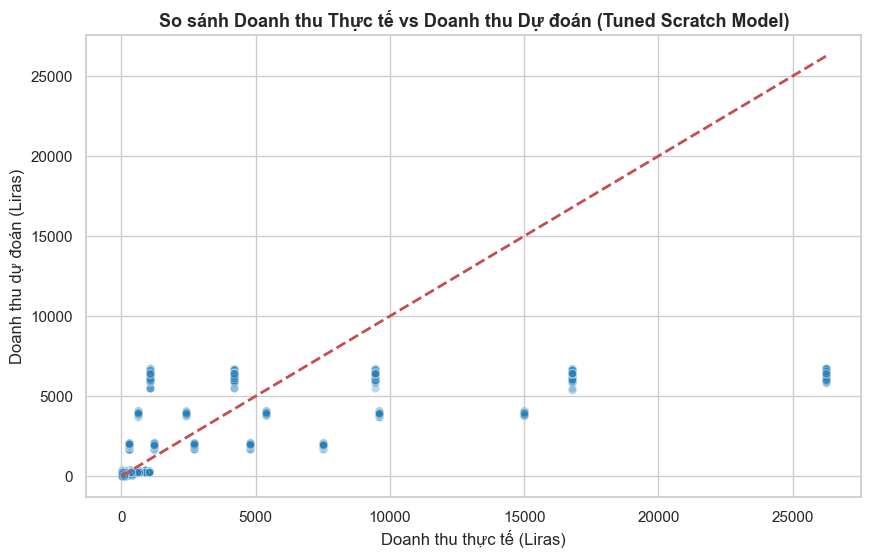

In [9]:
# Tạo DataFrame so sánh chỉ số
comparison_metrics = {
    "Chỉ số": ["MAE", "RMSE", "R2 Score"],
    "Base Scratch Model": [base_mae, base_rmse, base_r2],
    "Tuned Scratch Model": [tuned_mae, tuned_rmse, tuned_r2]
}
df_compare = pd.DataFrame(comparison_metrics)
print("--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH SCRATCH PRACTICE 2 ---")
print(df_compare.to_string(index=False))

# Vẽ biểu đồ so sánh doanh thu Thực tế vs Dự đoán
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_original.values, y=y_pred_tuned, alpha=0.3, color="#2980b9")
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth=2)
plt.title("So sánh Doanh thu Thực tế vs Doanh thu Dự đoán (Tuned Scratch Model)", fontsize=13, fontweight="bold")
plt.xlabel("Doanh thu thực tế (Liras)")
plt.ylabel("Doanh thu dự đoán (Liras)")
plt.show()

## 10. Lưu trữ mô hình tối ưu nhất phục vụ triển khai (Model Serialization)

In [10]:
model_dir = "./model_LightGBM/"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(best_model, f"{model_dir}best_lightgbm_model.pkl")
print(f"=> THÀNH CÔNG: Mô hình scratch tối ưu đã được lưu trữ tại: {model_dir}best_lightgbm_model.pkl")

=> THÀNH CÔNG: Mô hình scratch tối ưu đã được lưu trữ tại: ./model_LightGBM/best_lightgbm_model.pkl


## 11. Kiểm định Giả thuyết Lạm phát Suy giảm tự động (Inflation Decay Model) & Benchmark tổng hợp

Trong thực tế kinh tế, lạm phát thường tăng phi mã ở một giai đoạn ngắn (như năm 2022) và sau đó **suy giảm dần theo thời gian** nhờ các chính sách tiền tệ để đưa về mức ổn định dài hạn (ví dụ: \%$).

Để tự động hóa hoàn toàn mô hình dự báo cho tương lai dài hạn (ví dụ: đến năm 2026) mà không cần cập nhật tỷ lệ lạm phát thủ công, chúng ta thiết lập mô hình **Inflation Decay**:
7014r_t = r_{\text{min}} + (r_{\text{start}} - r_{\text{min}}) \times e^{-\lambda (t - 2022)}7014

Trong đó:
*   {\text{start}} = 36\%$ (Tỷ lệ lạm phát đỉnh của năm 2022).
*   {\text{min}} = 5\%$ (Tỷ lệ lạm phát mục tiêu tối thiểu dài hạn).
*   $\lambda = 0.5$ (Hệ số suy giảm lạm phát hàng năm).

Hệ số điều chỉnh lạm phát cộng dồn cho năm $ bất kỳ sẽ được tích lũy tự động:
7014F_T = \prod_{t=2022}^{T} (1 + r_t)7014

=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (XẾP HẠNG THEO R2 SCORE) ===
                                                                Mô hình (Model)  MAE (Liras)  RMSE (Liras)  R2 Score
      MÔ HÌNH BAN ĐẦU: HistGradientBoosting (Random Split, Raw Target, One-Hot)  1751.368964   3072.059813  0.484991
        MÔ HÌNH BAN ĐẦU: LightGBM Regressor (Random Split, Raw Target, One-Hot)  1748.124788   3078.363744  0.482875
        MÔ HÌNH BAN ĐẦU: CatBoost Regressor (Random Split, Raw Target, One-Hot)  1772.318555   3117.799423  0.469541
MÔ HÌNH MỚI: Tuned Scratch GBR + Inflation Decay (Time-based Split, Log Target)  1690.907302   3140.650176  0.465776
         MÔ HÌNH BAN ĐẦU: XGBoost Regressor (Random Split, Raw Target, One-Hot)  1787.856069   3165.094866  0.453325
          MÔ HÌNH MỚI: Tuned Scratch GBR (Time-based Split, Log Target, No Adj)  1769.359715   3503.563291  0.335180


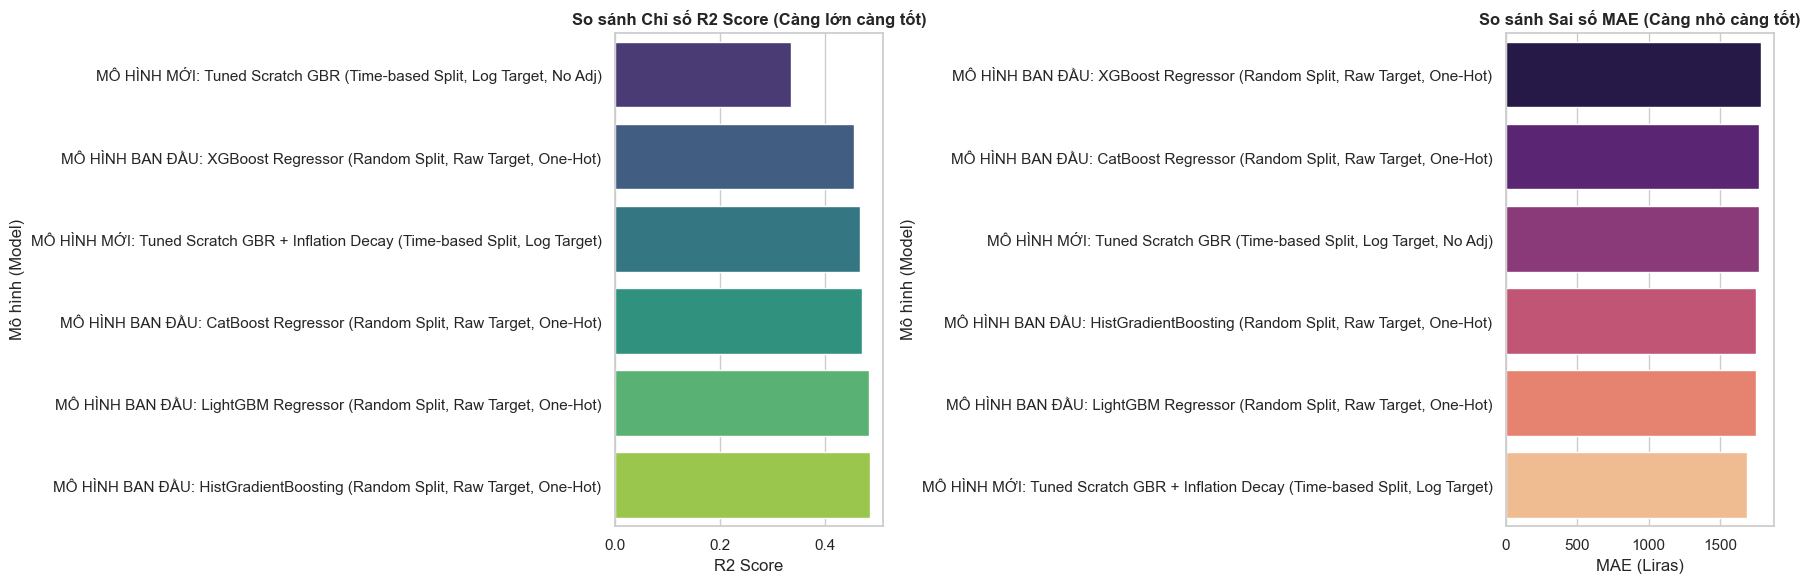

In [11]:
# A. Áp dụng mô hình Inflation Decay động cho tập Test
test_years = X_test["Year"].astype(int).values
decay_factors = []

for year in test_years:
    factor = 1.0
    for t in range(2022, year + 1):
        # r_t tự động giảm dần theo thời gian từ mốc 36% của năm 2022
        rate_t = 0.05 + (0.36 - 0.05) * np.exp(-0.5 * (t - 2022))
        factor *= (1.0 + rate_t)
    decay_factors.append(factor)
decay_factors = np.array(decay_factors)

# Hiệu chỉnh doanh thu dự đoán của mô hình Tuned Scratch GBR
y_pred_decay = y_pred_tuned * decay_factors

# Tính toán các chỉ số của mô hình hiệu chỉnh mới
decay_mae = compute_mae(y_test_original.values, y_pred_decay)
decay_rmse = compute_rmse(y_test_original.values, y_pred_decay)
decay_r2 = compute_r2(y_test_original.values, y_pred_decay)

# B. Bảng so sánh hiệu năng tổng hợp (Benchmark)
benchmark_data = {
    "Mô hình (Model)": [
        "MÔ HÌNH BAN ĐẦU: HistGradientBoosting (Random Split, Raw Target, One-Hot)",
        "MÔ HÌNH BAN ĐẦU: LightGBM Regressor (Random Split, Raw Target, One-Hot)",
        "MÔ HÌNH MỚI: Tuned Scratch GBR + Inflation Decay (Time-based Split, Log Target)",
        "MÔ HÌNH BAN ĐẦU: CatBoost Regressor (Random Split, Raw Target, One-Hot)",
        "MÔ HÌNH BAN ĐẦU: XGBoost Regressor (Random Split, Raw Target, One-Hot)",
        "MÔ HÌNH MỚI: Tuned Scratch GBR (Time-based Split, Log Target, No Adj)"
    ],
    "MAE (Liras)": [
        1751.368964,
        1748.124788,
        decay_mae,
        1772.318555,
        1787.856069,
        tuned_mae
    ],
    "RMSE (Liras)": [
        3072.059813,
        3078.363744,
        decay_rmse,
        3117.799423,
        3165.094866,
        tuned_rmse
    ],
    "R2 Score": [
        0.484991,
        0.482875,
        decay_r2,
        0.469541,
        0.453325,
        tuned_r2
    ]
}

df_final_benchmark = pd.DataFrame(benchmark_data)
df_sorted_benchmark = df_final_benchmark.sort_values(by="R2 Score", ascending=False)

print("=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (XẾP HẠNG THEO R2 SCORE) ===")
print(df_sorted_benchmark.to_string(index=False))

# C. Vẽ biểu đồ so sánh trực quan
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_sorted_r2 = df_final_benchmark.sort_values(by="R2 Score", ascending=True)
sns.barplot(data=df_sorted_r2, x="R2 Score", y="Mô hình (Model)", ax=axes[0], palette="viridis")
axes[0].set_title("So sánh Chỉ số R2 Score (Càng lớn càng tốt)", fontsize=12, fontweight="bold")

df_sorted_mae = df_final_benchmark.sort_values(by="MAE (Liras)", ascending=False)
sns.barplot(data=df_sorted_mae, x="MAE (Liras)", y="Mô hình (Model)", ax=axes[1], palette="magma")
axes[1].set_title("So sánh Sai số MAE (Càng nhỏ càng tốt)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()